In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
count = 0
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        count += 1
        if count == 5:
            break

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/sample_submission.csv
/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/train.csv
/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/test.csv
/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/images/32258b566bba41018fbfbc8cce95d6dc.png
/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/images/c653d938386447e58ab9a53f7100fa46.png


# Introduction

Chest X-ray imaging is one of the most widely used diagnostic tools in medical practice for detecting diseases related to the thoracic region such as lung infections, fluid accumulation, or structural abnormalities of the heart and lungs. However, manual analysis of X-ray images by radiologists can be time-consuming and prone to variability due to human factors.
In this assignment, the objective is to design and implement an automated deep learning system capable of detecting thoracic diseases from chest X-ray images. The task is formulated as a multi-class classification problem, where each X-ray image must be assigned to one of 20 possible pathology classes.
The system should learn patterns in medical imaging data and predict the most likely pathology class associated with the image.

# Objective

The goal of this assignment is to build a machine learning or deep learning model that can:
* Analyze chest X-ray images
* Identify the most probable thoracic pathology
* Assign the image to one of the 20 predefined classes

This task is formulated as a multi-class classification problem, where each input image belongs to exactly one pathology class.


In [2]:
import pandas as pd

train_df = pd.read_csv('/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/train.csv')

print(train_df.shape)
print(train_df.head())

(51043, 21)
                                     id  Atelectasis  Cardiomegaly  \
0  977df638b5294072ac81c369e2d9ecd0.png            0             0   
1  4f6dd5e39cd548df904b7319b13a40c5.png            0             0   
2  8772d25762484c2aa3f3e124d2ebcb30.png            1             0   
3  31caeb0fa0814858bf4591bc1c8d63ac.png            0             0   
4  9cd3df7acfbf4bb8a00466801469b08b.png            0             0   

   Consolidation  Edema  Effusion  Emphysema  Fibrosis  Hernia  Infiltration  \
0              0      0         0          0         0       0             0   
1              0      0         0          0         0       0             0   
2              0      0         0          0         0       0             0   
3              0      0         0          0         0       0             0   
4              0      0         0          0         0       0             0   

   ...  Nodule  Pleural_Thickening  Pneumonia  Pneumothorax  Pneumoperitoneum  \
0  ..

In [3]:
#Getting all column names except id
class_names = train_df.columns[1:]

#Converting into a single label
train_df['label'] = np.argmax(train_df[class_names].values, axis=1)

print(train_df[['id','label']].head())

                                     id  label
0  977df638b5294072ac81c369e2d9ecd0.png     19
1  4f6dd5e39cd548df904b7319b13a40c5.png     19
2  8772d25762484c2aa3f3e124d2ebcb30.png      0
3  31caeb0fa0814858bf4591bc1c8d63ac.png     19
4  9cd3df7acfbf4bb8a00466801469b08b.png     19


The dataset is highly imbalanced, with the ‘No Finding’ class dominating and other disease classes having significantly fewer samples. we need to handle it befor going to next analysis

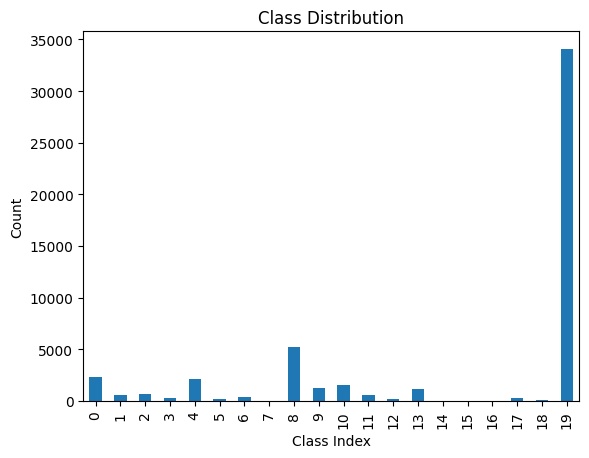

In [4]:
import matplotlib.pyplot as plt

train_df['label'].value_counts().sort_index().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class Index")
plt.ylabel("Count")
plt.show()

In [5]:
# To see some xrays of each class
from PIL import Image
def show_one_per_class(df, img_dir, class_names):
    
    plt.figure(figsize=(15, 10))
    
    for i, class_idx in enumerate(sorted(df['label'].unique())):
        
        sample = df[df['label'] == class_idx].iloc[0]
        
        img_path = os.path.join(img_dir, sample['id'])
        image = Image.open(img_path).convert('RGB')
        
        plt.subplot(4, 5, i+1)  
        plt.imshow(image)
        plt.title(f"Class {class_idx}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

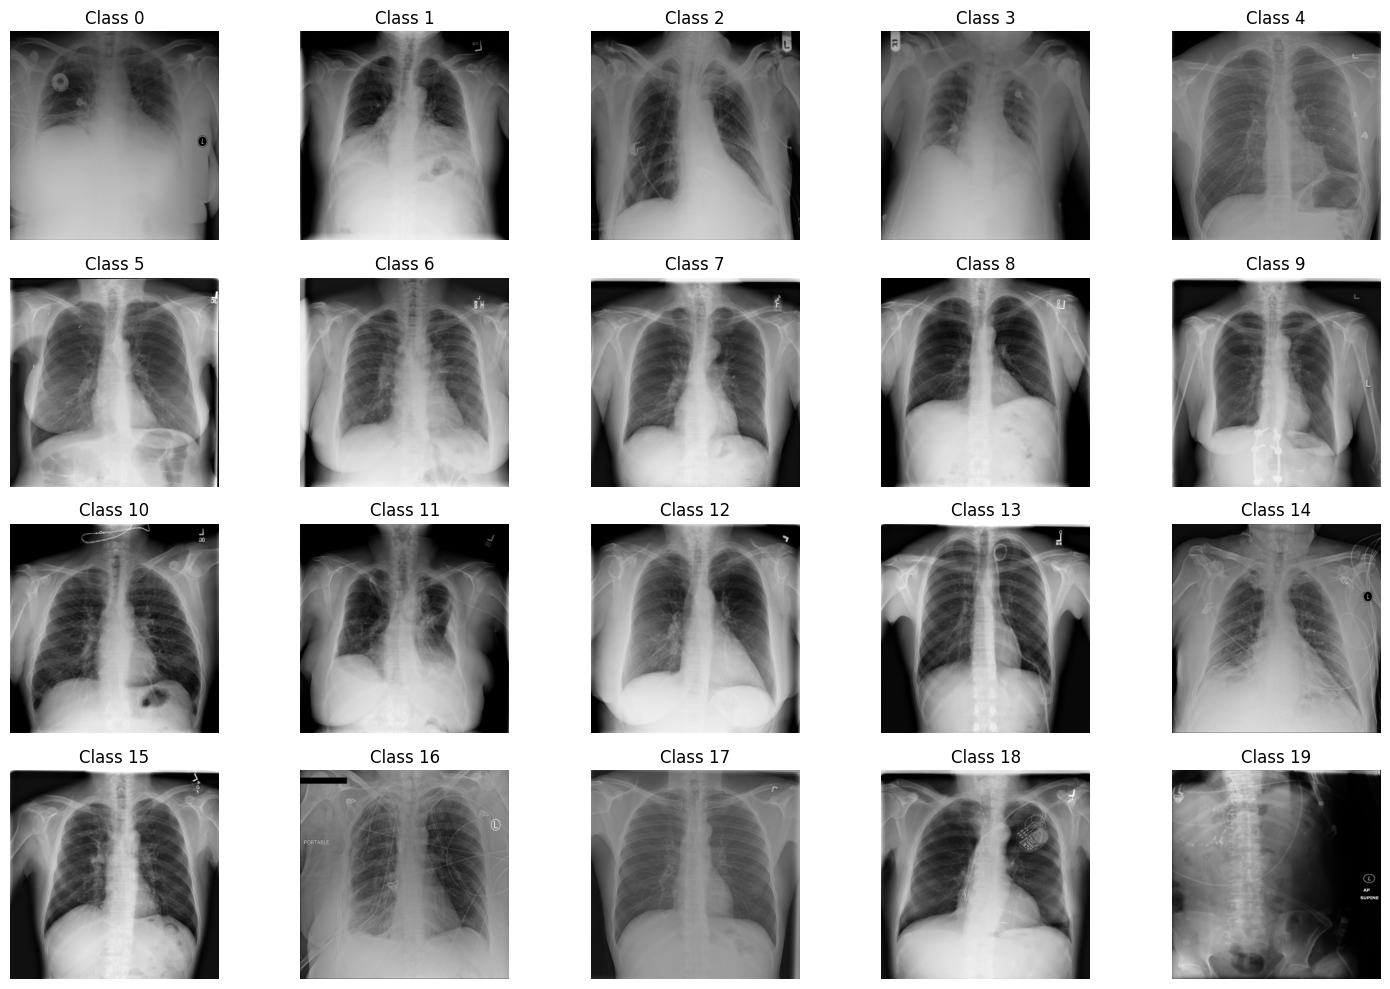

In [6]:
show_one_per_class(
    train_df,
    '/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/images',
    class_names
)

# Data preprocessing

In [7]:
from sklearn.utils.class_weight import compute_class_weight
import torch

MODEL_NAME = "resnet"   # resnet34/densenet/resnet
#Computing weights
class_weights = compute_class_weight(class_weight='balanced',classes=np.unique(train_df['label']),y =train_df['label'])

print(class_weights)

#Converting to tensor
class_weights = torch.tensor(class_weights,dtype=torch.float)

[1.08555934e+00 4.25358333e+00 3.92035330e+00 7.82868098e+00
 1.18374304e+00 1.48380814e+01 6.56079692e+00 6.89770270e+01
 4.90232424e-01 2.04335468e+00 1.67134905e+00 4.19761513e+00
 1.59509375e+01 2.29097846e+00 5.80034091e+01 5.10430000e+02
 1.06339583e+02 1.00478346e+01 2.80456044e+01 7.48892280e-02]


In [8]:
# Custom PyTorch Dataset class to load images dynamically, apply transformations, and return image-label pairs

# Import required libraries
from torch.utils.data import Dataset   # Base class for creating dataset
from PIL import Image                  # To open images
import os                              # To handle file paths


# Create Custom Dataset Class
class XrayDataset(Dataset):

    # Initialization (runs once when dataset is created)
    def __init__(self, df, img_dir, transform=None):
        self.df = df                    # dataframe with image names + labels
        self.img_dir = img_dir          # folder where images are stored
        self.transform = transform      # transformations (resize, tensor, etc.)


    # Length of dataset
    def __len__(self):
        return len(self.df)             # total number of images


    # Get one data point
    def __getitem__(self, idx):                                                      
        img_name = self.df.iloc[idx]['id']               #  Get image name    
        img_path = os.path.join(self.img_dir, img_name)  #  Create full image path       
        image = Image.open(img_path).convert('RGB')      #  Open image        
        
        if 'label' in self.df.columns:
            label = self.df.iloc[idx]['label']
        else:
            label = 0                                       # dummy label for test data

        if self.transform:
            image = self.transform(image)

        return image, label                           

In [9]:
#Defining transform
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),                        # Resize all images to 224x224 pixels
    transforms.RandomHorizontalFlip(),                    # Randomly flip images horizontally to increase data diversity
    transforms.RandomRotation(10),                        # Randomly rotate images within ±10 degrees to improve model robustness
    transforms.ToTensor(),                                # Convert image into PyTorch tensor and scale pixel values to [0,1]
    transforms.Normalize([0.485, 0.456, 0.406],           # Normalize using ImageNet mean and standard deviation
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [10]:
#Train–Validation Split
from sklearn.model_selection import train_test_split

train_df_split, val_df = train_test_split(
    train_df,
    test_size=0.2,                # 20% for validation
    stratify=train_df['label'],   # keeping class balance
    random_state=42
)

In [11]:
#Creating Dataset Objects
train_dataset = XrayDataset(
    df=train_df_split,             # Pass the training dataframe containing image IDs and labels
    img_dir='/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/images',  # Specify the directory where training images are stored
    transform=train_transform      # Apply training transformations (including augmentation) to images
)

val_dataset = XrayDataset(
    df=val_df,
    img_dir='/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/images',
    transform=val_transform
)

In [12]:
#Data Loader
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,              # Pass the training dataset object
    batch_size=32,              # Number of samples processed in one iteration (mini-batch size)
    shuffle=True                # Shuffle training data every epoch to improve model generalization
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False               # Do not shuffle validation data to ensure consistent evaluation
)

# Model Selection ResNet Model or DenseNet 

In [13]:
import torchvision.models as models      # Import pretrained deep learning models (ResNet, DenseNet, etc.)
import torch.nn as nn                    # Import neural network module for defining layers

if MODEL_NAME == "resnet":
    model = models.resnet18(pretrained=True)          # Load ResNet18 model with pretrained ImageNet weights
    model.fc = nn.Linear(model.fc.in_features, 20)    # Replace the final fully connected layer to match 20 output classes
elif MODEL_NAME == "resnet34":   
    model = models.resnet34(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, 20)
elif MODEL_NAME == "densenet":
    model = models.densenet121(pretrained=True)                # Load DenseNet121 model with pretrained ImageNet weights
    model.classifier = nn.Linear(model.classifier.in_features, 20)  # Replace the classifier layer to match 20 output classes
else:
    raise ValueError("Invalid MODEL_NAME")                                             

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 218MB/s]


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   # Select GPU if available, otherwise use CPU

model = model.to(device)                                             # Move the model to the selected device for computation

****Training****

In [15]:
#Defining optimizer
#for update model weights during training
import torch.optim as optim      

# Use Adam optimizer to update model weights with a learning rate of 0.00005
optimizer = optim.Adam(model.parameters(), lr=5e-5)    

In [16]:
#Loss Funtion
# Defining CrossEntropy loss with class weights to handle class imbalance
import torch.nn as nn

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))     # Gives more importance to rare classes (handles imbalance)
    

In [17]:
#Moving class weights to device
class_weights = class_weights.to(device)

In [18]:
#Training loop
# Import tqdm to display a progress bar during training
from tqdm import tqdm     

def train_model(model, train_loader, val_loader, epochs=10):
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")     # Print current epoch number
        
        # Training mode
        model.train()
        total_loss = 0                          # Initialize variable to track total training loss
        
        for images, labels in tqdm(train_loader):  # Loop through training data in batches with progress bar
              
            images = images.to(device)          # Move images to GPU/CPU
            labels = labels.to(device)          # Move labels to GPU/CPU
            
            optimizer.zero_grad()               # Reset gradients from previous iteration         
            outputs = model(images)             # Forward pass : compute predictions         
            loss = criterion(outputs, labels)   # Compute loss between predictions and true labels         
            loss.backward()                     # Backpropagation: compute gradients
            optimizer.step()                    # Update weights using optimizer
            
            total_loss += loss.item()           # Accumulate loss for this batch
        
        
        # Print average training loss for the epoch
        print(f"Training Loss: {total_loss / len(train_loader)}")    

In [19]:
#Initialize training
train_model(model, train_loader, val_loader, epochs=10)


Epoch 1/10


100%|██████████| 1277/1277 [09:10<00:00,  2.32it/s]


Training Loss: 2.6817264097597606

Epoch 2/10


100%|██████████| 1277/1277 [06:48<00:00,  3.13it/s]


Training Loss: 2.421272777866925

Epoch 3/10


...

Training Loss: 1.617334723338403

Epoch 9/10


100%|██████████| 1277/1277 [06:51<00:00,  3.11it/s]


Training Loss: 1.4764659701523457

Epoch 10/10


100%|██████████| 1277/1277 [06:59<00:00,  3.04it/s]

Training Loss: 1.37087108747933


In [20]:
#Evaluation
from sklearn.metrics import f1_score

def evaluate_model(model, val_loader):
    model.eval()                             # Set model to evaluation mode 
    
    y_true = []                              # List to store actual labels
    y_pred = []                              # List to store predicted labels
    
    with torch.no_grad():                    # Disable gradient computation (saves memory and speeds up evaluation)
        for images, labels in val_loader:    # Loop through validation data batch by batch
            
            images = images.to(device)       # Move images to GPU/CPU for computation
            
            outputs = model(images)          # Forward pass: get model predictions (logits)
            
            preds = torch.argmax(outputs, dim=1).cpu().numpy()     # Convert logits to predicted class labels (highest score)
            
            y_pred.extend(preds)             # Store predicted labels
            y_true.extend(labels.numpy())    # Store actual labels
    
    # Defining Custom Score function
    custom = 0
    for t, p in zip(y_true, y_pred):
        if t == p:
            custom += 1                     # Add +1 for correct prediction
        else:
            custom -= 6                     # Subtract 6 for incorrect prediction (penalty)
    
    custom_score = custom / len(y_true)     # Compute average custom score
    
    # defining Weighted F1 Score
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')
    
    return custom_score, weighted_f1

In [21]:
#calling the evaluation function
custom, f1 = evaluate_model(model, val_loader)

print("Custom Score:", custom)
print("Weighted F1 Score:", f1)

Custom Score: -4.3482221569203645
Weighted F1 Score: 0.29163381450238407


****Applying the Model on full test data****

In [22]:
#Loading test data
test_df = pd.read_csv('/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/test.csv')

print(test_df.head())

                                     id
0  7b647fbfcc874a7084a4470fc150e267.png
1  cc804b94d80c4a80a206298c307adfec.png
2  1df09c3becd04de995244caae36ddf57.png
3  044cac47cfdf4c8b90848c9e56c36bfa.png
4  a873523c43664a049c5e8f26add7ecb2.png


In [23]:
#Creating test dataset
test_dataset = XrayDataset(
    df=test_df,                   # Pass test dataframe containing only image IDs (no labels)
    img_dir='/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/images',  # Path to directory where test images are stored
    transform=val_transform       # Apply validation transformations (no augmentation, only resize + normalization)
)

In [24]:
#Test data loader
test_loader = DataLoader(
    test_dataset,                # Load test dataset
    batch_size=32,               # Process test data in batches of 32
    shuffle=False                # Do not shuffle to maintain correct order for submission
)

In [25]:
# Prediction
# Set model to evaluation mode (disable dropout, use fixed batchnorm stats)
model.eval()    

predictions = []                         # Initialize list to store predicted probabilities

with torch.no_grad():                    # Disable gradient computation for faster inference and lower memory usage
    for images, _ in test_loader:        # Loop through test data (labels are ignored as test data is unlabeled)
        
        images = images.to(device)       # Move images to GPU/CPU
        
        outputs = model(images)          # Forward pass: get raw model outputs 
        
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        # Convert to one-hot
        batch_preds = np.zeros((len(preds), len(class_names)),dtype=int)

        for i, p in enumerate(preds):
            batch_preds[i, p] = 1

        predictions.extend(batch_preds)
        

In [26]:
#Loading the submission file
sample_sub = pd.read_csv('/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/sample_submission.csv')

class_names = sample_sub.columns[1:]

In [27]:
#Creating submission file
submission = pd.DataFrame(predictions, columns=class_names)
submission.insert(0, 'id', test_df['id'])

submission.to_csv('sample_submission.csv', index=False)

In [28]:
submission.head()

,id,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,...,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,Pneumoperitoneum,Pneumomediastinum,Subcutaneous Emphysema,Tortuous Aorta,Calcification of the Aorta,No Finding
0,7b647fbfcc874a7084a4470fc150e267.png,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,cc804b94d80c4a80a206298c307adfec.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,1df09c3becd04de995244caae36ddf57.png,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,044cac47cfdf4c8b90848c9e56c36bfa.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,a873523c43664a049c5e8f26add7ecb2.png,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
